# Análise de Dados - Loterias Caixa
<img src='http://loterias.caixa.gov.br/wps/wcm/connect/c6e414a7-ab65-4a06-b812-745798a9f362/10_Lotofacil.png?MOD=AJPERES&CACHEID=c6e414a7-ab65-4a06-b812-745798a9f362' width=200>

---
#### Adição de bibliotecas, download, extração e leitura do arquivo de dados (Pandas DataFrame).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import io
import requests
from zipfile import ZipFile

%matplotlib inline

arq = requests.get('http://www1.caixa.gov.br/loterias/_arquivos/loterias/D_lotfac.zip')   
ZipFile(io.BytesIO(arq.content)).extractall()
dflis = pd.read_html('d_lotfac.htm', thousands='.', decimal=',') # lista de DataFrames
df = dflis[0] # lista[0] contém o primeiro DataFrame
df

,Concurso,Data Sorteio,Bola1,Bola2,Bola3,Bola4,Bola5,Bola6,Bola7,Bola8,Bola9,Bola10,Bola11,Bola12,Bola13,Bola14,Bola15,Arrecadacao_Total,Ganhadores_15_Números,Cidade,UF,Ganhadores_14_Números,Ganhadores_13_Números,Ganhadores_12_Números,Ganhadores_11_Números,Valor_Rateio_15_Números,Valor_Rateio_14_Números,Valor_Rateio_13_Números,Valor_Rateio_12_Números,Valor_Rateio_11_Números,Acumulado_15_Números,Estimativa_Premio,Valor_Acumulado_Especial
0,1,29/09/2003,18,20,25,23,10,11,24,14,6,2,13,9,5,16,3,0.0,5,NaN,BA,154,4645,48807,257593,49765.82,689.84,10.0,4.0,2.0,0.0,0.0,0.00
1,1,29/09/2003,18,20,25,23,10,11,24,14,6,2,13,9,5,16,3,0.0,5,NaN,PR,154,4645,48807,257593,49765.82,689.84,10.0,4.0,2.0,0.0,0.0,0.00
2,1,29/09/2003,18,20,25,23,10,11,24,14,6,2,13,9,5,16,3,0.0,5,NaN,SP,154,4645,48807,257593,49765.82,689.84,10.0,4.0,2.0,0.0,0.0,0.00
3,1,29/09/2003,18,20,25,23,10,11,24,14,6,2,13,9,5,16,3,0.0,5,NaN,SP,154,4645,48807,257593,49765.82,689.84,10.0,4.0,2.0,0.0,0.0,0.00
4,1,29/09/2003,18,20,25,23,10,11,24,14,6,2,13,9,5,16,3,0.0,5,NaN,SP,154,4645,48807,257593,49765.82,689.84,10.0,4.0,2.0,0.0,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8357,2054,10/10/2020,11,23,5,3,12,2,22,10,1,7,17,19,21,8,14,14182757.5,4,ITAQUAQUECETUBA,SP,426,11171,112276,541675,221102.97,621.86,25.0,10.0,5.0,0.0,1500000.0,7761345.69
8358,2054,10/10/2020,11,23,5,3,12,2,22,10,1,7,17,19,21,8,14,14182757.5,4,Canal Eletrônico,XX,426,11171,112276,541675,221102.97,621.86,25.0,10.0,5.0,0.0,1500000.0,7761345.69
8359,2055,13/10/2020,14,15,3,21,4,1,2,7,18,5,23,16,19,11,25,18532490.0,3,BRASÍLIA,DF,218,9740,113412,633765,504509.00,1455.75,25.0,10.0,5.0,0.0,1500000.0,8127521.58
8360,2055,13/10/2020,14,15,3,21,4,1,2,7,18,5,23,16,19,11,25,18532490.0,3,CURITIBA,PR,218,9740,113412,633765,504509.00,1455.75,25.0,10.0,5.0,0.0,1500000.0,8127521.58


---
### Remove as colunas 'Cidade' e 'UF' e as linhas repetidas.


In [3]:
dfsr = df.drop(columns=['Cidade', 'UF']) # remove as colunas que não se repetem
dfsr.drop_duplicates(inplace = True) # remove as linhas repetidas
dfsr.reset_index(drop = True, inplace = True) # reinicia os índices da tabela
dfsr

,Concurso,Data Sorteio,Bola1,Bola2,Bola3,Bola4,Bola5,Bola6,Bola7,Bola8,Bola9,Bola10,Bola11,Bola12,Bola13,Bola14,Bola15,Arrecadacao_Total,Ganhadores_15_Números,Ganhadores_14_Números,Ganhadores_13_Números,Ganhadores_12_Números,Ganhadores_11_Números,Valor_Rateio_15_Números,Valor_Rateio_14_Números,Valor_Rateio_13_Números,Valor_Rateio_12_Números,Valor_Rateio_11_Números,Acumulado_15_Números,Estimativa_Premio,Valor_Acumulado_Especial
0,1,29/09/2003,18,20,25,23,10,11,24,14,6,2,13,9,5,16,3,0.0,5,154,4645,48807,257593,49765.82,689.84,10.0,4.0,2.0,0.0,0.0,0.00
1,2,06/10/2003,23,15,5,4,12,16,20,6,11,19,24,1,9,13,7,0.0,1,184,6232,81252,478188,596323.70,1388.95,10.0,4.0,2.0,0.0,0.0,0.00
2,3,13/10/2003,20,23,12,8,6,1,7,11,14,4,16,10,9,17,24,0.0,2,158,6897,96244,608211,400623.70,2173.36,10.0,4.0,2.0,0.0,0.0,0.00
3,4,20/10/2003,16,5,25,24,23,8,12,2,17,18,1,10,4,19,13,0.0,1,258,9569,123912,706657,902226.02,1498.72,10.0,4.0,2.0,0.0,0.0,0.00
4,5,27/10/2003,15,13,20,2,11,24,9,16,4,23,25,12,8,19,1,0.0,2,472,14736,195636,860992,380017.55,687.49,10.0,4.0,2.0,0.0,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2050,2051,07/10/2020,22,25,16,23,18,12,9,4,10,2,19,1,3,7,20,19331330.0,1,289,11127,133169,724649,1365807.36,1415.61,25.0,10.0,5.0,0.0,1200000.0,6880984.42
2051,2052,08/10/2020,10,25,3,17,6,18,14,4,20,24,12,1,13,8,16,15404535.0,2,401,10681,110468,538534,567127.53,847.26,25.0,10.0,5.0,0.0,1500000.0,7155400.97
2052,2053,09/10/2020,3,4,9,13,20,24,12,11,16,18,22,21,17,15,23,19739000.0,1,171,8225,126375,670879,1620159.55,1986.61,25.0,10.0,5.0,0.0,1200000.0,7547375.06
2053,2054,10/10/2020,11,23,5,3,12,2,22,10,1,7,17,19,21,8,14,14182757.5,4,426,11171,112276,541675,221102.97,621.86,25.0,10.0,5.0,0.0,1500000.0,7761345.69


---
### Seleciona apenas as colunas dos números sorteados de cada concurso e calcula a qtde de vezes que cada número foi sorteado. Mostra também os números menos e mais sorteados.
<ul>
<li>Na primeira linha, dfsr.iloc[:, 2:17] também pode ser usado.
</ul>


In [15]:
dfbolas = dfsr.loc[:, 'Bola1':'Bola15'].to_numpy()
qtde_sor = np.array([[n, (dfbolas == n).sum()] for n in range(1, 26)]) # números e qtdes sorteadas (ou numpy.count_nonzero(df == x))

mi, ma = min(qtde_sor[:, 1]), max(qtde_sor[:, 1])
lmi = qtde_sor[:, 0][(qtde_sor[:, 1] == mi)] # seleciona os números que têm a mesma qtde de mi (qtde mínima).
lma = qtde_sor[:, 0][(qtde_sor[:, 1] == ma)] # o mesmo para a qtde máxima.
print(qtde_sor)
print(f'\nMínimo = {mi} {lmi}\nMáximo = {ma} {lma}')

[[   1 1242]
 [   2 1242]
 [   3 1257]
 [   4 1253]
 [   5 1236]
 [   6 1193]
 [   7 1204]
 [   8 1170]
 [   9 1212]
 [  10 1267]
 [  11 1260]
 [  12 1221]
 [  13 1271]
 [  14 1240]
 [  15 1222]
 [  16 1184]
 [  17 1226]
 [  18 1227]
 [  19 1236]
 [  20 1259]
 [  21 1218]
 [  22 1237]
 [  23 1237]
 [  24 1265]
 [  25 1246]]

Mínimo = 1170 [8]
Máximo = 1271 [13]


---
### Gráfico de barras que mostra a qtde sorteada de cada número (ORDEM CRESCENTE). Destaque para os 15 mais sorteados.

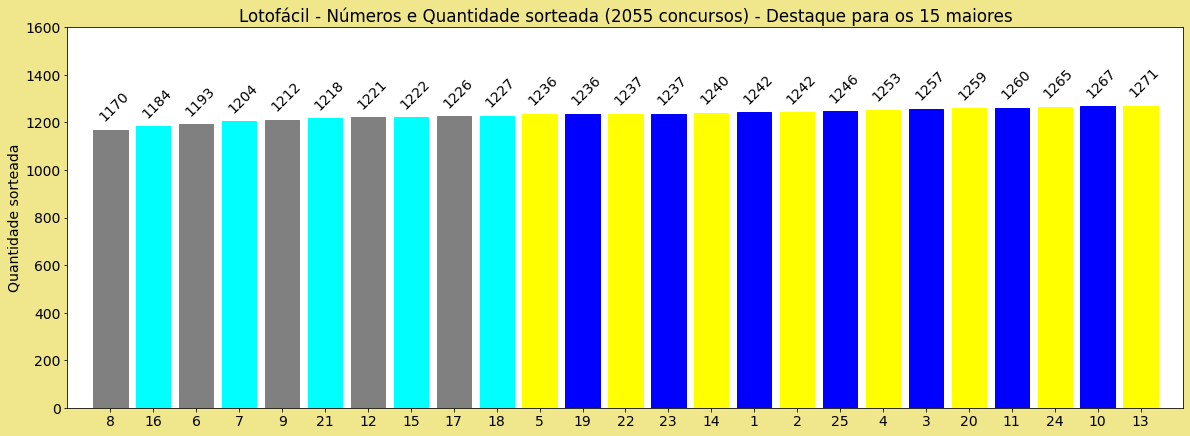

In [16]:
qtde_sor_ord = np.array(sorted(qtde_sor, key=lambda x: x[1])) # ordena os números de acordo com a qtde de sorteios

plt.rcParams['figure.figsize'] = (20, 7) # tamanho da imagem
plt.rcParams['figure.facecolor'] = 'khaki'
plt.rcParams['font.size'] = 14 # tamanho da fonte dos textos
plt.axis([0, 26, 0, 1600]) # intervalo dos eixos x e y

# gráfico de barras horiz. X e Y são listas
barras = plt.bar(range(1, 26), qtde_sor_ord[:, 1], tick_label=qtde_sor_ord[:, 0])

plt.title(f'Lotofácil - Números e Quantidade sorteada ({dfsr.shape[0]} concursos) - Destaque para os 15 maiores') # shape contém qtde de linhas e colunas (tuple)
plt.ylabel('Quantidade sorteada')
for i in range(25):
    cor1, cor2 = 'gray', 'cyan'
    if i >= 10: # cor diferente para os 15 valores com mais frequência nos sorteios
        cor1, cor2 = 'yellow', 'blue'
    barras[i].set_color(cor1 if i % 2 == 0 else cor2)
for i, bar in enumerate(barras):
    plt.text(bar.get_x() + bar.get_width() + 0.1, 1.02 * bar.get_height(), qtde_sor_ord[i, 1],
             ha='right', va='bottom', rotation=45)
plt.show()

---
### Gráfico de 'torta' que mostra a qtde e a porcentagem de prêmios distribuídos por estado (UF).

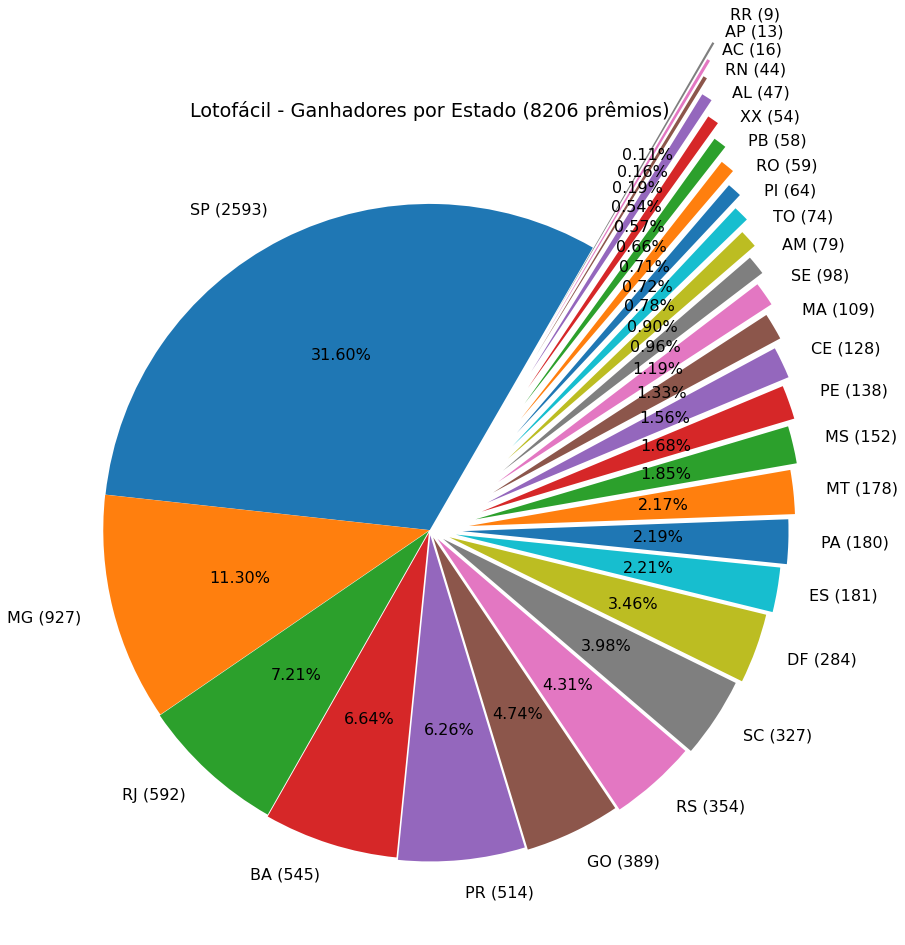

In [20]:
dfuf = df[df['UF'] != '&nbsp']
dfuf_vc = dfuf['UF'].value_counts()
plt.rcParams['figure.figsize'] = (15, 15) # tamanho da imagem
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['font.size'] = 16 # tamanho da fonte dos textos
plt.pie(dfuf_vc, [x ** 2 * 0.001 for x in range(len(dfuf_vc))], 
        [dfuf_vc.index[i] + ' (' + str(val) + ')' for i, val in enumerate(dfuf_vc)], 
        autopct='%.2f%%', startangle=60)
plt.title(f'Lotofácil - Ganhadores por Estado ({sum(dfuf_vc)} prêmios)') 
plt.show()